In [18]:
!wget -N "https://github.com/Project-MONAI/MONAI-extra-test-data/releases/download/0.8.1/MedNIST.tar.gz"
!tar -xzf MedNIST.tar.gz
!mkdir -p Medical
!mv MedNIST Medical/Medical_train
!rm MedNIST.tar.gz

--2026-10-06 11:39:36--  https://github.com/Project-MONAI/MONAI-extra-test-data/releases/download/0.8.1/MedNIST.tar.gz
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/366729051/8d8a7f6b-8cd3-490c-b480-337298f4d385?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-10-06T11%3A29%3A38Z&rscd=attachment%3B+filename%3DMedNIST.tar.gz&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-10-06T10%3A29%3A22Z&ske=2026-10-06T11%3A29%3A38Z&sks=b&skv=2018-11-09&sig=v8tFEfmvjg6sCQGAOH81oJPikvJ2pJkbUNSsf%2Ffl2Qo%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc5MTI4NDkzMiwibmJmIjoxNzkxMjgzMTMyLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJ

In [19]:
test_dir = "Medical/Medical_test" 
train_dir = "Medical/Medical_train"

In [20]:
import os
import numpy as np
import pandas as pd
import random, datetime, shutil, math

In [21]:
def prep_test_data(med, train_dir, test_dir):
    pop = os.listdir(train_dir + '/' + med)
    test_data = random.sample(pop, 2000)
    os.makedirs(test_dir + '/' + med, exist_ok=True)
    for f in test_data:
        shutil.move(train_dir + '/' + med + '/' + f, test_dir + '/' + med + '/')

In [22]:
for medi in os.listdir(train_dir):
    if os.path.isdir(train_dir + '/' + medi):
        prep_test_data(medi, train_dir, test_dir)

In [24]:
target_classes = [d for d in os.listdir(train_dir) if os.path.isdir(train_dir + '/' + d)]  
num_classes = len(target_classes)
print('Number of target classes: ', num_classes)
print(list(enumerate(target_classes)))

Number of target classes:  6
[(0, 'Hand'), (1, 'CXR'), (2, 'AbdomenCT'), (3, 'BreastMRI'), (4, 'HeadCT'), (5, 'ChestCT')]


In [25]:
target_classes = os.listdir(test_dir)
num_classes = len(target_classes)
print('Number of target classes: ', num_classes)
print(list(enumerate(target_classes)))

Number of target classes:  6
[(0, 'Hand'), (1, 'CXR'), (2, 'AbdomenCT'), (3, 'BreastMRI'), (4, 'HeadCT'), (5, 'ChestCT')]


In [27]:
training_set_distribution = [len(os.listdir(os.path.join(train_dir, dir))) for dir in os.listdir(train_dir)]
testing_set_distribution = [len(os.listdir(os.path.join(test_dir, dir))) for dir in os.listdir(test_dir)]

In [28]:
def show_mri(med):
    num = len(med)
    if num == 0:
        return None
    rows = int(math.sqrt(num))
    cols = (num + 1) // rows
    f, axs = plt.subplots(rows, cols)
    fig = 0
    for b in med:
        img = image.load_img(b)
        row = fig // cols
        col = fig % cols
        axs[row, col].imshow(img)
        fig += 1
    plt.show()

In [31]:
import matplotlib.pyplot as plt
import matplotlib.image as imread
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

I0000 00:00:1791284222.664585    7993 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


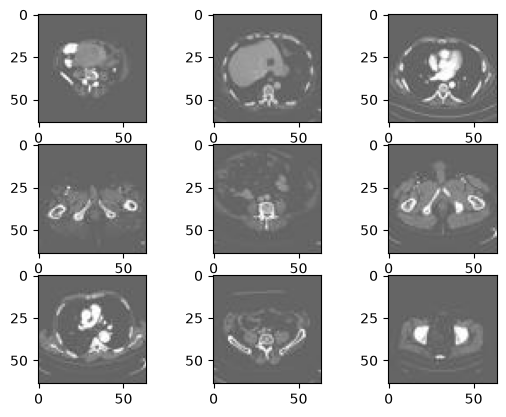

In [32]:
dir_name = os.path.join(train_dir, "AbdomenCT")
all_images = [os.path.join(dir_name, fname) for fname in os.listdir(dir_name)]
show_mri(all_images[:9])

In [33]:
image_size = (32, 32, 3)
datagen = ImageDataGenerator(rescale=1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=True)
training_set = datagen.flow_from_directory(train_dir, target_size=image_size[:2], batch_size=32, class_mode='categorical', shuffle=False)
validation_set = datagen.flow_from_directory(test_dir, target_size=image_size[:2], batch_size=32, class_mode='categorical', shuffle=False)

Found 46954 images belonging to 6 classes.
Found 12000 images belonging to 6 classes.


In [34]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import plot_model

In [35]:
es = EarlyStopping(monitor='val_acc', mode='max', verbose=1, patience=7)
filepath = "modelMedicalMNIST.h5"
ckpt = ModelCheckpoint(filepath, monitor='acc', verbose=1, save_best_only=True, mode='max')
rlp = ReduceLROnPlateau(monitor='acc', patience=3, verbose=1)

In [36]:
def cnn(image_size, num_classes):
    classifier = Sequential()
    classifier.add(Conv2D(64, (5,5), input_shape=image_size, activation='relu', padding='same'))
    classifier.add(MaxPooling2D(pool_size=(2,2)))
    classifier.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    classifier.add(MaxPooling2D(pool_size=(2,2)))
    classifier.add(Flatten())
    classifier.add(Dense(num_classes, activation='softmax'))
    classifier.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
    return classifier

In [37]:
neuralnetwork_cnn = cnn(image_size, num_classes)
neuralnetwork_cnn.summary()

/home/ubuntu24/PROJECTS/Disease-Classification-Project/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1791285171.544577    7993 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │        49,158 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,878 (499.52 KB)

 Trainable params: 127,878 (499.52 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
history = neuralnetwork_cnn.fit(training_set, validation_data=validation_set, callbacks=[es, ckpt, rlp], epochs=5)

Epoch 1/5


I0000 00:00:1791285516.506461    7993 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


1468/1468 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - acc: 0.9153 - loss: 0.2405
Epoch 1: acc improved from None to 0.91534, saving model to modelMedicalMNIST.h5



Epoch 1: finished saving model to modelMedicalMNIST.h5
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 138s 93ms/step - acc: 0.9153 - loss: 0.2405 - val_acc: 0.9908 - val_loss: 0.0417 - learning_rate: 0.0010
Epoch 2/5
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - acc: 0.9756 - loss: 0.1001
Epoch 2: acc improved from 0.91534 to 0.97559, saving model to modelMedicalMNIST.h5



Epoch 2: finished saving model to modelMedicalMNIST.h5
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 122s 83ms/step - acc: 0.9756 - loss: 0.1001 - val_acc: 0.9926 - val_loss: 0.0296 - learning_rate: 0.0010
Epoch 3/5
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - acc: 0.9937 - loss: 0.0263
Epoch 3: acc improved from 0.97559 to 0.99365, saving model to modelMedicalMNIST.h5



Epoch 3: finished saving model to modelMedicalMNIST.h5
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 161s 109ms/step - acc: 0.9937 - loss: 0.0263 - val_acc: 0.9963 - val_loss: 0.0125 - learning_rate: 0.0010
Epoch 4/5
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - acc: 0.9882 - loss: 0.0429
Epoch 4: acc did not improve from 0.99365
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 161s 110ms/step - acc: 0.9882 - loss: 0.0429 - val_acc: 0.9959 - val_loss: 0.0151 - learning_rate: 0.0010
Epoch 5/5
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - acc: 0.9958 - loss: 0.0212
Epoch 5: acc improved from 0.99365 to 0.99585, saving model to modelMedicalMNIST.h5



Epoch 5: finished saving model to modelMedicalMNIST.h5
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 120s 81ms/step - acc: 0.9958 - loss: 0.0212 - val_acc: 0.9977 - val_loss: 0.0083 - learning_rate: 0.0010


<Axes: >

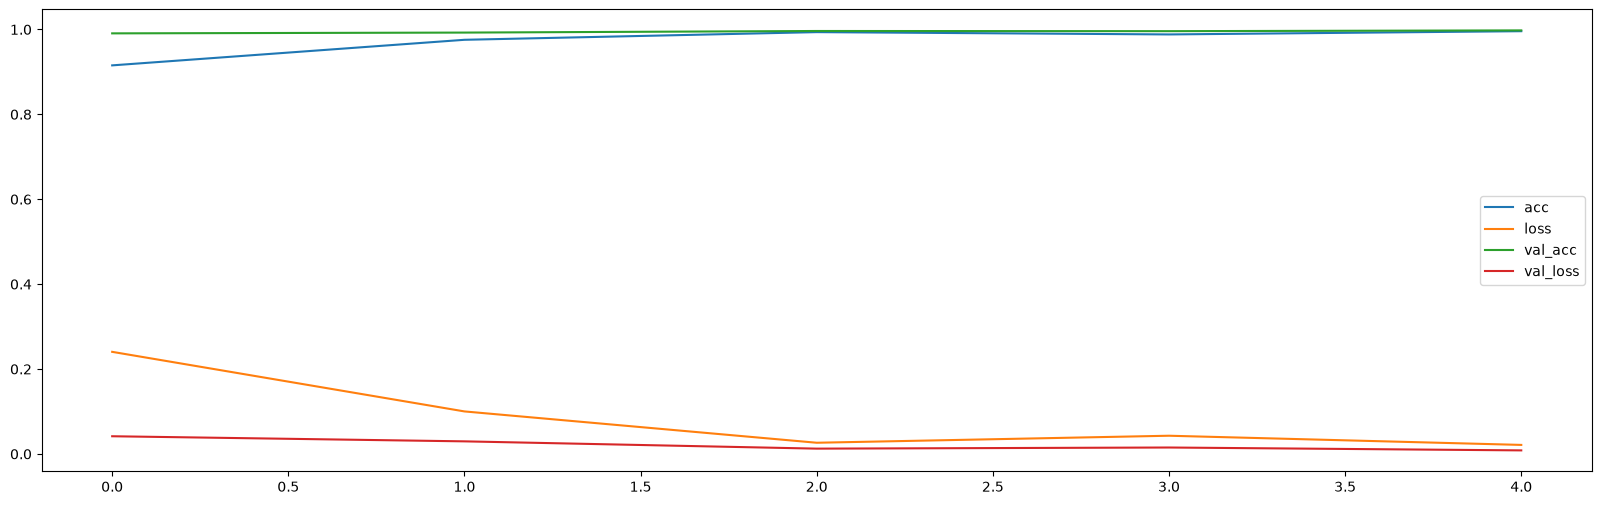

In [41]:
fig, ax = plt.subplots(figsize=(20, 6))
pd.DataFrame(history.history).iloc[:,:-1].plot(ax=ax)

In [44]:
batch_size = 32
validation_set.reset()
pred = neuralnetwork_cnn.predict(validation_set, steps=math.ceil(306/batch_size))
predicted_class_indices = np.argmax(pred, axis=1)
labels = (validation_set.class_indices)
labels = dict((v,k) for k,v in labels.items())
predictions = [labels[k] for k in predicted_class_indices]

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


In [45]:
filenames = validation_set.filenames[0]
results = pd.DataFrame({"Filename":filenames, "Predictions":predictions})

In [46]:
display(results.head(15))

,Filename,Predictions
0,AbdomenCT/000004.jpeg,AbdomenCT
1,AbdomenCT/000004.jpeg,AbdomenCT
2,AbdomenCT/000004.jpeg,AbdomenCT
3,AbdomenCT/000004.jpeg,AbdomenCT
4,AbdomenCT/000004.jpeg,AbdomenCT
5,AbdomenCT/000004.jpeg,AbdomenCT
6,AbdomenCT/000004.jpeg,AbdomenCT
7,AbdomenCT/000004.jpeg,AbdomenCT
8,AbdomenCT/000004.jpeg,AbdomenCT
9,AbdomenCT/000004.jpeg,AbdomenCT
